In [15]:
#Import library
import pandas as pd # data processing
import numpy as np #linear algebra
import seaborn as sns #visualization
import os
import matplotlib.pyplot as plt #visualization
%matplotlib inline
import itertools
import warnings
warnings.filterwarnings("ignore")
import io
import plotly.offline as py #visualization
py.init_notebook_mode(connected=True) #visualization
import plotly.graph_objs as go #visualization
import plotly.tools as tls #visualization
import plotly.figure_factory as ff #visualization

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.metrics import f1_score
import statsmodels.api as sm
from sklearn.metrics import precision_score,recall_score
from yellowbrick.classifier import DiscriminationThreshold

In [6]:
df = pd.read_csv("newdata.csv",index_col=0)[1:]
df.head()

,default,housing,loan,deposit,customerID,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,poutcome_other,poutcome_success,poutcome_unknown,age,balance,day,duration,campaign,pdays,previous
1,0,0,0,1,1,1,0,0,0,0,...,0,0,1,1.243502,-0.459290,-1.266714,3.150669,-0.553952,-0.481437,-0.362947
2,0,1,0,1,2,0,0,0,0,0,...,0,0,1,-0.016502,-0.079367,-1.266714,2.926185,-0.553952,-0.481437,-0.362947
3,0,1,0,1,3,0,0,0,0,0,...,0,0,1,1.159502,0.294663,-1.266714,0.595007,-0.553952,-0.481437,-0.362947
4,0,0,0,1,4,1,0,0,0,0,...,0,0,1,1.075501,-0.416180,-1.266714,0.865539,-0.186286,-0.481437,-0.362947
5,0,1,1,1,5,0,0,0,0,1,...,0,0,1,0.067499,-0.473246,-1.266714,0.546081,-0.186286,-0.481437,-0.362947


### Splitting train and test data


In [7]:
train,test = train_test_split(df,test_size = .25 ,random_state = 111)
train = train.dropna()
test = test.dropna()

In [9]:
#customer id col
Id_col = ['customerID']
df['customerID'] = df.index

#Target columns
target_col = ["deposit"]

##seperating dependent and independent variables
cols = [i for i in df.columns if i not in Id_col + target_col]
train_X = train[cols]
train_Y = train[target_col]
test_X = test[cols]
test_Y = test[target_col]


LogisticRegression(multi_class='ovr', n_jobs=1, solver='liblinear')

 Classification report: 
               precision    recall  f1-score   support

           0       0.81      0.86      0.83      1459
           1       0.83      0.77      0.80      1297

    accuracy                           0.82      2756
   macro avg       0.82      0.82      0.82      2756
weighted avg       0.82      0.82      0.82      2756

Accuracy Score :  0.8174891146589259
Area under curve :  0.8150371263256855 



c:\Users\ADMIN\anaconda3\lib\site-packages\plotly\tools.py:461: DeprecationWarning:

plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead



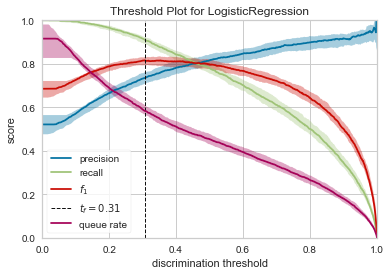

In [16]:
#Function attributes
#dataframe - processed dataframe
#Algorithm - Algorithm used
#training_x - predictor variables dataframe(training)
#testing_x - predictor variables dataframe(testing)
#training_y - target variable(training)
#training_y - target variable(testing)
#cf - ["coefficients","features"](cooefficients for logistic
#regression,features for tree based models)

#threshold_plot - if True returns threshold plot for model
def bank_deposit_prediction(algorithm,training_x,testing_x, training_y,testing_y,cols,cf,threshold_plot):
    #model
    algorithm.fit(training_x,training_y)
    predictions = algorithm.predict(testing_x)
    probabilities = algorithm.predict_proba(testing_x)

    #coefficient
    if cf == "coefficients" :
        coefficients = pd.DataFrame(algorithm.coef_.ravel())
    elif cf == "features" :
        coefficients = pd.DataFrame(algorithm.feature_importances_)
    
    column_df = pd.DataFrame(cols)
    coef_sumry = (pd.merge(coefficients,column_df,left_index= True,right_index= True, how = "left"))
    coef_sumry.columns = ["coefficients","features"]
    coef_sumry = coef_sumry.sort_values(by = "coefficients",ascending = False)

    print (algorithm)
    print ("\n Classification report: \n", classification_report(testing_y,predictions))
    print ("Accuracy Score : ",accuracy_score(testing_y,predictions))

    #confusion matrix
    conf_matrix = confusion_matrix(testing_y,predictions)
    #roc_auc_score
    model_roc_auc = roc_auc_score(testing_y,predictions)
    print ("Area under curve : ",model_roc_auc,"\n")
    fpr,tpr,thresholds = roc_curve(testing_y,probabilities[:,1])
    
    #plot confusion matrix
    trace1 = go.Heatmap(z = conf_matrix ,x = ["Not deposit","Deposit"],y = ["Not deposit","Deposit"],showscale = False,colorscale = "Picnic",name = "matrix")

    #plot roc curve
    trace2 = go.Scatter(x = fpr,y = tpr,name = "Roc : " + str(model_roc_auc),line = dict(color = ('rgb(22, 96, 167)'),width = 2))
    trace3 = go.Scatter(x = [0,1],y=[0,1],line = dict(color = ('rgb(205, 12, 24)'),width = 2,dash = 'dot'))
    #plot coeffs
    trace4 = go.Bar(x = coef_sumry["features"],y = coef_sumry["coefficients"],name = "coefficients",marker = dict(color = coef_sumry["coefficients"],colorscale = "Picnic",line = dict(width = .6,color = "black")))
    #subplots
    fig = tls.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], subplot_titles=('Confusion Matrix','Receiver operating characteristic','Feature Importances'))
    fig.append_trace(trace1,1,1)
    fig.append_trace(trace2,1,2)
    fig.append_trace(trace3,1,2)
    fig.append_trace(trace4,2,1)
    
    fig['layout'].update(showlegend=False, title="Model performance" ,
                autosize = False,height = 900,width = 800,
                plot_bgcolor = 'rgba(240,240,240, 0.95)',
                paper_bgcolor = 'rgba(240,240,240, 0.95)',
                margin = dict(b = 195))
    fig["layout"]["xaxis2"].update(dict(title = "false positive rate"))
    fig["layout"]["yaxis2"].update(dict(title = "true positive rate"))
    fig["layout"]["xaxis3"].update(dict(showgrid = True,tickfont = dict(size = 10),tickangle = 90))

    py.iplot(fig)

    if threshold_plot == True :
        visualizer = DiscriminationThreshold(algorithm)
        visualizer.fit(training_x,training_y)
        visualizer.poof()

    fig.show(renderer="colab")

logit = LogisticRegression(
    C=1.0, class_weight=None, dual=False,fit_intercept=True,
    intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
    penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
    verbose=0, warm_start=False)

bank_deposit_prediction(logit,train_X,test_X,train_Y,test_Y,cols,"coefficients",threshold_plot = True)



